In [3]:
import pandas as pd

In [4]:
import torch

# 修复 RDNA2 (RX 6600M) MIOpen 兼容性问题
torch.backends.cudnn.enabled = False

print('PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
print('Device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.9.1+rocmsdk20251207
GPU available: True
Device count: 1
GPU: AMD Radeon RX 6600M


In [5]:
df = pd.read_csv("F:/python/nih/BBox_List_2017.csv")
print(df.head())

        Image Index Finding Label     Bbox [x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

           h]  Unnamed: 6  Unnamed: 7  Unnamed: 8  
0   79.186441         NaN         NaN         NaN  
1  313.491525         NaN         NaN         NaN  
2  216.949153         NaN         NaN         NaN  
3   55.322034         NaN         NaN         NaN  
4   78.101695         NaN         NaN         NaN  


finding lesion label

In [6]:
print(df.columns)
print(df['Finding Label'].value_counts())
####print(df['Finding Label'].unique())

Index(['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8'],
      dtype='str')
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64


In [7]:
nodule_df = df[df['Finding Label'] == 'Nodule']
print(nodule_df.head())
print(len(nodule_df))

          Image Index Finding Label     Bbox [x           y           w  \
668  00001688_000.png        Nodule  667.496296  276.317460  122.446561   
669  00004547_003.png        Nodule  899.386243  690.251852   53.096296   
670  00023078_000.png        Nodule  741.180952  687.001058   52.012698   
671  00023068_003.png        Nodule  351.085714  747.682540   35.758730   
672  00013911_000.png        Nodule  118.112169  483.284656   85.604233   

             h]  Unnamed: 6  Unnamed: 7  Unnamed: 8  
668  150.620106         NaN         NaN         NaN  
669   58.514286         NaN         NaN         NaN  
670   48.761905         NaN         NaN         NaN  
671   33.591534         NaN         NaN         NaN  
672  101.858201         NaN         NaN         NaN  
79


第九步：读取第一行数据

In [8]:
row = df.iloc[0]  ##above code, this will get the first row of the dataframe. You can change the index to get different rows.
print(row)

Image Index      00013118_008.png
Finding Label         Atelectasis
Bbox [x                225.084746
y                      547.019217
w                       86.779661
h]                      79.186441
Unnamed: 6                    NaN
Unnamed: 7                    NaN
Unnamed: 8                    NaN
Name: 0, dtype: object


In [9]:
import os

img_dir = "F:/python/nih/images_001/images/"
files = os.listdir(img_dir)

print("total images:", len(files))

total images: 4999


In [10]:
# only keep the rows in df where the 'Image Index' is in the list of files
df_subset = df[df['Image Index'].isin(files)]

print("CSV total images:", len(df))
print("images_001 available:", len(df_subset))

CSV total images: 984
images_001 available: 39


In [11]:
print(df.columns)

Index(['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8'],
      dtype='str')


重命名列

In [12]:
df = df.rename(columns={
    'Bbox [x': 'Bbox_x',
    'y': 'Bbox_y',
    'w': 'Bbox_w',
    'h]': 'Bbox_h'
})

print(df.columns)

Index(['Image Index', 'Finding Label', 'Bbox_x', 'Bbox_y', 'Bbox_w', 'Bbox_h',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'],
      dtype='str')


In [13]:
df_subset = df[df['Image Index'].isin(files)]
print("available lines:", len(df_subset))
row = df_subset.iloc[0]
print(row)

available lines: 39
Image Index      00000808_002.png
Finding Label         Atelectasis
Bbox_x                 558.101695
Bbox_y                 384.307352
Bbox_w                  227.79661
Bbox_h                 167.050847
Unnamed: 6                    NaN
Unnamed: 7                    NaN
Unnamed: 8                    NaN
Name: 12, dtype: object


打开图片

imgpath: F:/python/nih/images_001/images/00000808_002.png


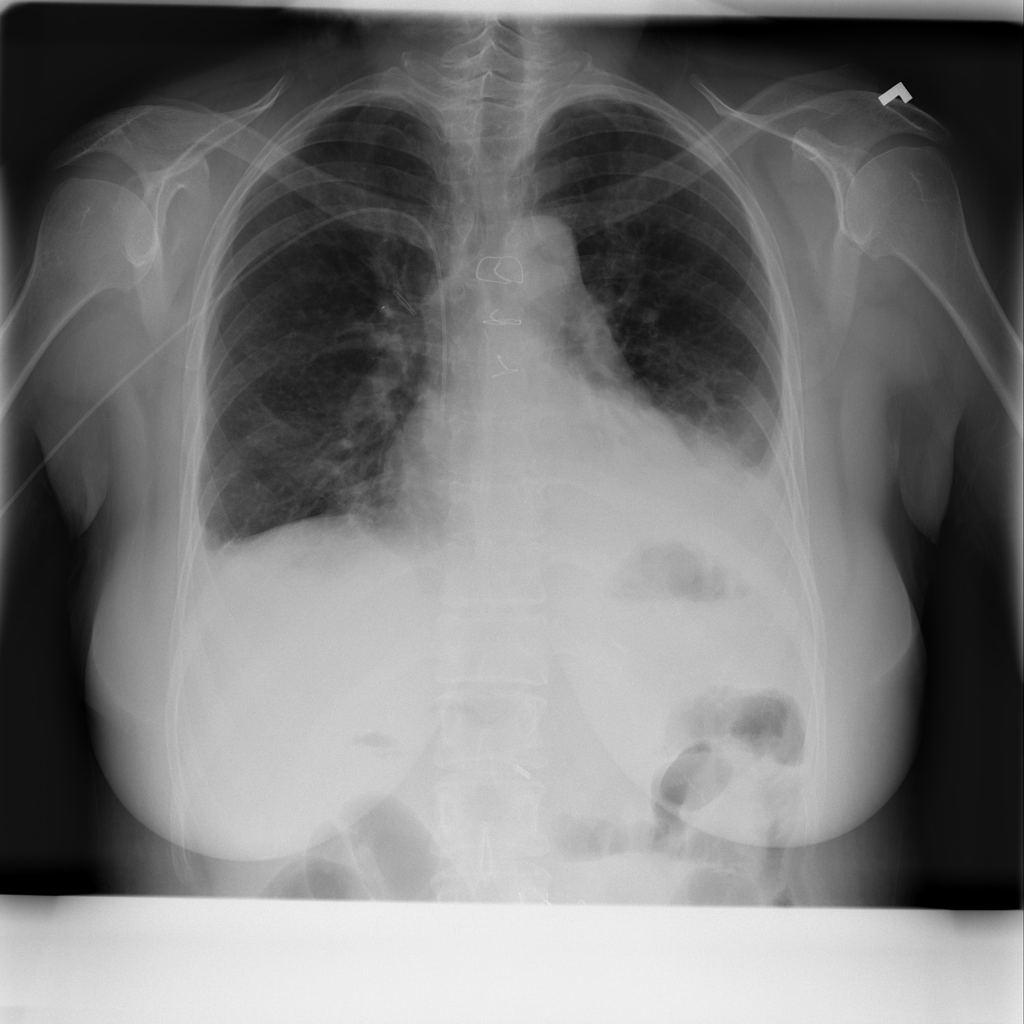

In [14]:
from PIL import Image
import os

img_name = row['Image Index']
img_path = os.path.join(img_dir, img_name)

print("imgpath:", img_path)

image = Image.open(img_path)
image

画出 bounding box

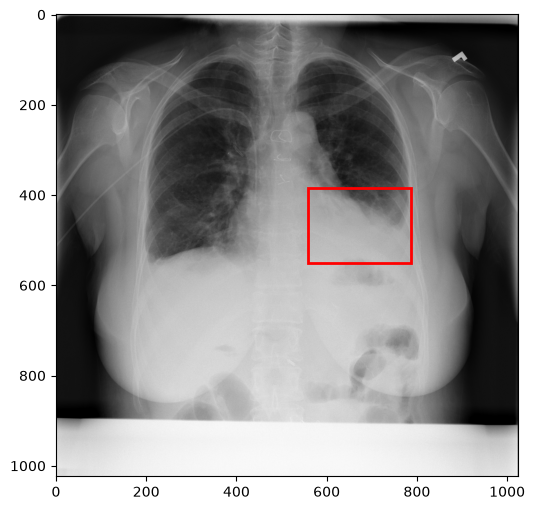

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# get bbox
x = row['Bbox_x']
y = row['Bbox_y']
w = row['Bbox_w']
h = row['Bbox_h']

fig, ax = plt.subplots(1, figsize=(6,6))
ax.imshow(image, cmap='gray')

rect = patches.Rectangle((x, y), w, h,
                         linewidth=2,
                         edgecolor='red',
                         facecolor='none')

ax.add_patch(rect)
plt.show()

PyTorch Dataset。

第一步：准备标签编码
在建立 Dataset 之前，先把类别变成数字

In [16]:
# Get all unique classes from the 'Finding Label' column
classes = df_subset['Finding Label'].unique().tolist()
print("lesion categories:", classes)

# create a mapping from class names to integer labels
class_to_id = {c: i for i, c in enumerate(classes)}
print("lesion category mapping:", class_to_id)

# apply the mapping to the 'Finding Label' column
df_subset = df_subset.copy()
df_subset['label'] = df_subset['Finding Label'].map(class_to_id)

print(df_subset[['Image Index', 'Finding Label', 'label']].head())

lesion categories: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Pneumonia', 'Pneumothorax']
lesion category mapping: {'Atelectasis': 0, 'Cardiomegaly': 1, 'Effusion': 2, 'Infiltrate': 3, 'Mass': 4, 'Pneumonia': 5, 'Pneumothorax': 6}
         Image Index Finding Label  label
12  00000808_002.png   Atelectasis      0
14  00000865_006.png   Atelectasis      0
17  00000181_061.png   Atelectasis      0
20  00000468_033.png   Atelectasis      0
34  00001170_046.png   Atelectasis      0


second step: create a Dataset class

In [17]:
import torch ##it is a deep learning framework that provides a wide range of tools for building and training neural networks. It is widely used in both academia and industry for various machine learning tasks, including computer vision, natural language processing, and reinforcement learning.
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class NIHDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True) ## this is to reset the index of the dataframe
        self.img_dir = img_dir ## this is the directory where the images are stored
        self.transform = transform ## this is the transformation to be applied to the images

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 读取图片
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('RGB')
        
        # 读取标签
        label = row['label']
        
        # 预处理
        if self.transform:
            image = self.transform(image)
        
        return image, label

define transform


In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),##piexls
    transforms.ToTensor(), ##tensor 是 PyTorch 里的基本数据结构，简单理解就是“多维数组”。 一维就是向量，二维就是矩阵，三维就是图像数据。


    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],##mean of the ImageNet dataset, which is commonly used for pretraining deep learning models. These values are used to normalize the pixel values of the input images to have zero mean and unit variance.
        std=[0.229, 0.224, 0.225]
    )
])

step 4: test a dataset object

In [19]:
dataset = NIHDataset(df_subset, img_dir, transform)

print("Dataset size:", len(dataset))

# 取第一个样本
image, label = dataset[0]

print("image shape:", image.shape)
print("label:", label)
print("lesion category:", classes[label])

Dataset size: 39
image shape: torch.Size([3, 224, 224])
label: 0
lesion category: Atelectasis


第五步：建立 DataLoader

In [20]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

# 测试一个 batch
images, labels = next(iter(dataloader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels)

Batch image shape: torch.Size([8, 3, 224, 224])
Batch labels: tensor([0, 0, 5, 0, 0, 0, 0, 1])


deploy CNN

In [21]:
import torch
import torch.nn as nn

# ROCm 下禁用 MIOpen（RDNA2 兼容性修复）
torch.backends.cudnn.enabled = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 54 * 54, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# 初始化模型
num_classes = len(classes)
model = SimpleCNN(num_classes=num_classes).to(device)
print(model)
print("Number of classes:", num_classes)

使用设备: cuda
SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=186624, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)
Number of classes: 7


第二步：定义 Loss 和 Optimizer

In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()#交叉熵损失，适用于分类任务；输入应是模型的原始 logits（未经过 softmax），标签是类别索引（LongTensor）。CrossEntropyLoss 内部做了 log-softmax + NLL。
optimizer = optim.Adam(model.parameters(), lr=0.001)#学习率为 0.001（可调

第三步：训练循环

Epoch [1/10] Loss: 91.8064
Epoch [2/10] Loss: 18.2055
Epoch [3/10] Loss: 8.4749
Epoch [4/10] Loss: 2.4732
Epoch [5/10] Loss: 4.8871
Epoch [6/10] Loss: 0.8216
Epoch [7/10] Loss: 0.4877
Epoch [8/10] Loss: 2.9721
Epoch [9/10] Loss: 1.6934
Epoch [10/10] Loss: 0.6347
Training complete!


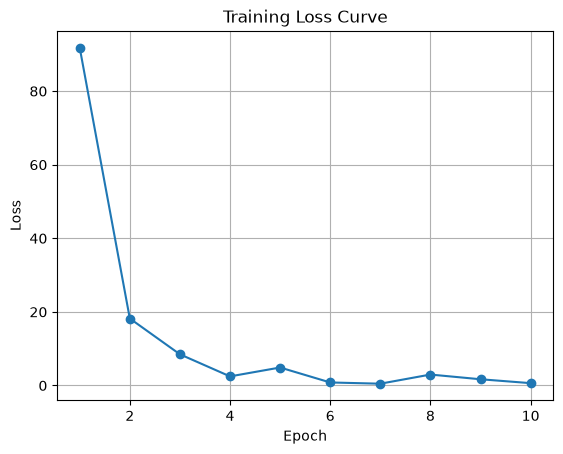

In [23]:
num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}')

print("Training complete!")

# plot loss curve
plt.plot(range(1, num_epochs+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

第四步：测试预测

In [24]:
model.eval()

# 前 10 个样本预测
first_predictions = []
with torch.no_grad():
    for idx in range(min(10, len(dataset))):
        image, label = dataset[idx]
        image = image.to(device)
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)
        first_predictions.append((idx, classes[label], classes[predicted.item()]))

print("First 10 predictions:")
for idx, true_label, pred_label in first_predictions:
    print(f"{idx}: true={true_label}, pred={pred_label}")

# 准确率
correct = 0
total = 0
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

First 10 predictions:
0: true=Atelectasis, pred=Atelectasis
1: true=Atelectasis, pred=Atelectasis
2: true=Atelectasis, pred=Atelectasis
3: true=Atelectasis, pred=Atelectasis
4: true=Atelectasis, pred=Atelectasis
5: true=Atelectasis, pred=Atelectasis
6: true=Atelectasis, pred=Atelectasis
7: true=Atelectasis, pred=Atelectasis
8: true=Atelectasis, pred=Atelectasis
9: true=Atelectasis, pred=Atelectasis
Accuracy: 94.87%


dection dataset

In [70]:
class NIHDetectionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 读取图片
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('RGB')
        
        # 原始图片尺寸
        orig_w, orig_h = image.size
        
        # 读取标签
        label = int(row['label'])
        
        # 读取 bbox 并归一化到 0~1
        x = row['Bbox_x'] / orig_w
        y = row['Bbox_y'] / orig_h
        w = row['Bbox_w'] / orig_w
        h = row['Bbox_h'] / orig_h
        
        bbox = torch.tensor([x, y, w, h], dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        
        return image, label, bbox

create dataset

In [71]:
det_dataset = NIHDetectionDataset(df_subset, img_dir, transform)

image, label, bbox = det_dataset[0]

print("image shape:", image.shape)
print("labels:", label, "→", classes[label])
print("bboxes:", bbox)

image shape: torch.Size([3, 224, 224])
labels: 0 → Atelectasis
bboxes: tensor([0.5450, 0.3753, 0.2225, 0.1631])


check dataloader

In [72]:
det_dataloader = DataLoader(
    det_dataset,
    batch_size=8,
    shuffle=True
)

# 测试一个 batch
images, labels, bboxes = next(iter(det_dataloader))

print("image batch shape:", images.shape)
print("labels batch:", labels)
print("bboxes batch shape:", bboxes.shape)

image batch shape: torch.Size([8, 3, 224, 224])
labels batch: tensor([0, 0, 0, 1, 0, 0, 0, 6])
bboxes batch shape: torch.Size([8, 4])


In [73]:
class SimpleDetectionCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleDetectionCNN, self).__init__()
        
        # 特征提取（和之前一样）
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),#3 is the number of input channels RGB, 32 is the number of output channels, and 3x3 kernel_size is the size of the convolutional filter.
            nn.BatchNorm2d(32),#Batch normalization is a technique used to improve the training of deep neural networks by normalizing the inputs to each layer.
            nn.ReLU(),
            nn.MaxPool2d(2),#MaxPool2d(2) 后：[batch, 32, 111, 111]（下采样 /2，向下取整
            
            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)#第二次 MaxPool2d(2) 后：[batch, 64, 54, 54]（109/2 = 54 向下取整
        )
        
        # 共享特征层
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 54 * 54, 256),#展平后全连接输入维度就是 64 * 54 * 54，这就是 nn.Linear(64 * 54 * 54, 256) 中的 645454 的来源
            nn.ReLU()
        )
        
        # 分类头
        self.cls_head = nn.Linear(256, num_classes)#输出维度是 num_classes，因为要输出每个类别的概率
        
        # bbox 回归头
        self.bbox_head = nn.Sequential(
            nn.Linear(256, 4),
            nn.Sigmoid()  # 输出 0~1 之间
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.shared(x)
        
        cls_out = self.cls_head(x)
        bbox_out = self.bbox_head(x)
        
        return cls_out, bbox_out

intialize model

In [74]:
print("使用设备:", device)

# 分类 Loss
cls_criterion = nn.CrossEntropyLoss()

# bbox 回归 Loss
bbox_criterion = nn.MSELoss()

# 初始化模型（移到 GPU）
model = SimpleDetectionCNN(num_classes=len(classes)).to(device)
print(model)

# 优化器
optimizer = optim.Adam(model.parameters(), lr=0.001)

SimpleDetectionCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (shared): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=186624, out_features=256, bias=True)
    (2): ReLU()
  )
  (cls_head): Linear(in_features=256, out_features=7, bias=True)
  (bbox_head): Sequential(
    (0): Linear(in_features=256, out_features=4, bias=True)
    (1): Sigmoid()
  )
)


traning model

In [75]:
num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels, bboxes in det_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)

        cls_out, bbox_out = model(images)
        cls_loss = cls_criterion(cls_out, labels)
        bbox_loss = bbox_criterion(bbox_out, bboxes)
        total_loss = cls_loss + bbox_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    avg_loss = running_loss / len(det_dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Total Loss: {avg_loss:.4f} '
          f'Cls Loss: {cls_loss:.4f} '
          f'Bbox Loss: {bbox_loss:.4f}')

print("training complete!")

Epoch [1/5] Total Loss: 2.1422 Cls Loss: 2.0703 Bbox Loss: 0.0620
Epoch [2/5] Total Loss: 2.1469 Cls Loss: 2.0947 Bbox Loss: 0.0724
Epoch [3/5] Total Loss: 2.1444 Cls Loss: 2.0346 Bbox Loss: 0.1017
Epoch [4/5] Total Loss: 2.1467 Cls Loss: 1.9601 Bbox Loss: 0.0945
Epoch [5/5] Total Loss: 2.1454 Cls Loss: 2.0841 Bbox Loss: 0.0747
training complete!


evluate model

In [78]:
model.eval()

with torch.no_grad():
    image, label, bbox = det_dataset[0]
    image = image.to(device)

    cls_out, bbox_out = model(image.unsqueeze(0))

    _, predicted = torch.max(cls_out, 1)

    print(f'detected class: {classes[predicted.item()]}')
    print(f'ground truth class: {classes[label]}')
    print(f'detected bbox: {bbox_out[0].cpu().numpy()}')
    print(f'actual bbox: {bbox.numpy()}')

detected class: Effusion
ground truth class: Atelectasis
detected bbox: [0.53215784 0.47110242 0.5354141  0.5130035 ]
actual bbox: [0.5450212  0.37530014 0.22245763 0.16313559]


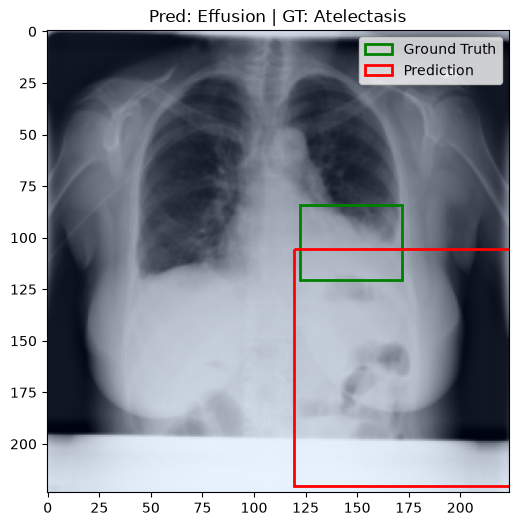

In [79]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

model.eval()

with torch.no_grad():
    image_tensor, label, true_bbox = det_dataset[0]
    image_gpu = image_tensor.to(device)
    cls_out, bbox_out = model(image_gpu.unsqueeze(0))
    _, predicted = torch.max(cls_out, 1)
    pred_bbox = bbox_out[0].cpu().numpy()

# 把 tensor 转回图片
image_np = image_tensor.permute(1, 2, 0).numpy()
image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

fig, ax = plt.subplots(1, figsize=(6,6))
ax.imshow(image_np)

# 真实框（绿色）
tx, ty = true_bbox[0]*224, true_bbox[1]*224
tw, th = true_bbox[2]*224, true_bbox[3]*224

true_rect = patches.Rectangle(
    (tx, ty), tw, th,
    linewidth=2, edgecolor='green', facecolor='none', label='Ground Truth'
)

# 预测框（红色）
px, py = pred_bbox[0]*224, pred_bbox[1]*224
pw, ph = pred_bbox[2]*224, pred_bbox[3]*224

pred_rect = patches.Rectangle(
    (px, py), pw, ph,
    linewidth=2, edgecolor='red', facecolor='none', label='Prediction'
)

ax.add_patch(true_rect)
ax.add_patch(pred_rect)
ax.legend()
ax.set_title(f'Pred: {classes[predicted.item()]} | GT: {classes[label]}')
plt.show()

yolo

In [34]:
import os

# 创建文件夹
os.makedirs("F:/python/nih/yolo_dataset/images", exist_ok=True)
os.makedirs("F:/python/nih/yolo_dataset/labels", exist_ok=True)

# 转换
for _, row in df_subset.iterrows():
    img_name = row['Image Index']
    label_id = int(row['label'])
    
    # 归一化坐标
    x_center = (row['Bbox_x'] + row['Bbox_w'] / 2) / 1024
    y_center = (row['Bbox_y'] + row['Bbox_h'] / 2) / 1024
    w = row['Bbox_w'] / 1024
    h = row['Bbox_h'] / 1024
    
    # 写 txt
    label_file = img_name.replace('.png', '.txt')
    with open(f"F:/python/nih/yolo_dataset/labels/{label_file}", 'w') as f:
        f.write(f"{label_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

print("label transform complete!")
print(len(df_subset), "labels have been transformed!")

label transform complete!
39 labels have been transformed!


复制图片到 YOLO 文件夹

In [35]:
import shutil

for img_name in df_subset['Image Index']:
    src = os.path.join(img_dir, img_name)
    dst = f"F:/python/nih/yolo_dataset/images/{img_name}"
    shutil.copy(src, dst)

print("images copied!")

images copied!


 data.yaml

In [ ]:
yaml_content = f"""
path: F:/python/nih/yolo_dataset
train: images
val: images

nc: {len(classes)} ##number of classes
names: {classes}  ##lesion categories
"""

with open("F:/python/nih/yolo_dataset/data.yaml", 'w') as f: ##this line opens the file "data.yaml" in write mode ('w') and assigns the file object to the variable f. If the file does not exist, it will be created. If it already exists, its contents will be overwritten.
    f.write(yaml_content)

print("data.yaml written!")
print(yaml_content)

data.yaml written!

path: F:/python/nih/yolo_dataset
train: images
val: images

nc: 7
names: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Pneumonia', 'Pneumothorax']



start traning yolo

In [ ]:
from ultralytics import YOLO

model = YOLO("F:/python/pytorch_cpuy/yolov8n.pt")

model.train(
    data="F:/python/nih/yolo_dataset/data.yaml",
    epochs=30,##number of epochs to train for
    imgsz=640,##image size for training
    batch=4,##number of samples per batch
    project="F:/python/nih/yolo_results",
    name="exp1",
    plots=False,       # disable plots during training
    save=True,         # save the model after training
    save_txt=False,
    save_conf=False,
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.78 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.75  Python-3.13.1 torch-2.12.1+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:/python/nih/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=F:/python/pytorch_cpuy/yolov8n.pt, momentum=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000218A95499B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

读取训练指标

In [83]:
import pandas as pd

results_csv = "F:/python/nih/yolo_results/exp1/results.csv"

df_results = pd.read_csv(results_csv)

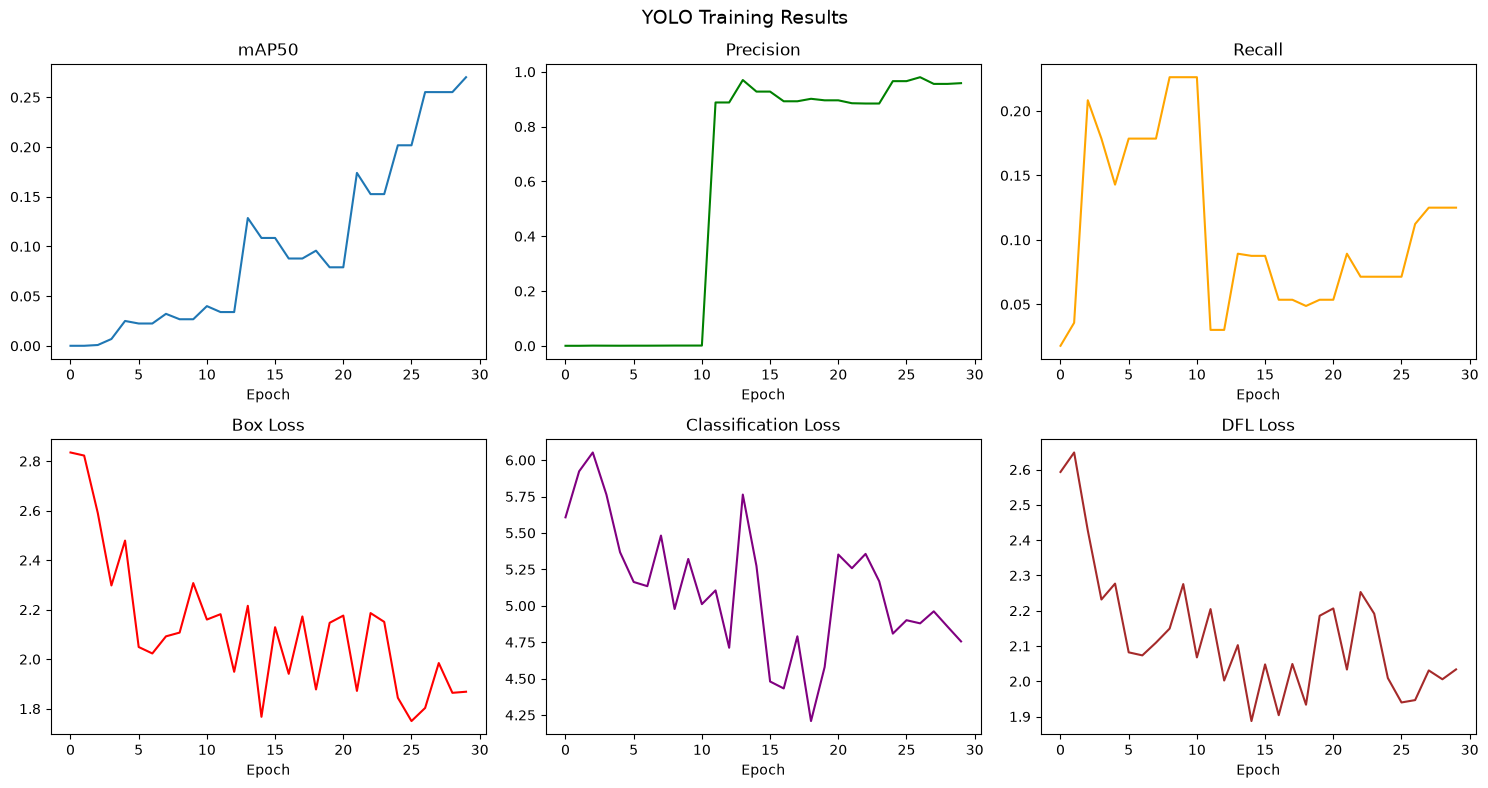

In [84]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))


df_results.columns = df_results.columns.str.strip()

# 1. mAP50
axes[0,0].plot(df_results["metrics/mAP50(B)"])
axes[0,0].set_title("mAP50")
axes[0,0].set_xlabel("Epoch")

# 2. Precision
axes[0,1].plot(df_results["metrics/precision(B)"], color='green')
axes[0,1].set_title("Precision")
axes[0,1].set_xlabel("Epoch")

# 3. Recall
axes[0,2].plot(df_results["metrics/recall(B)"], color='orange')
axes[0,2].set_title("Recall")
axes[0,2].set_xlabel("Epoch")

# 4. Box Loss
axes[1,0].plot(df_results["train/box_loss"], color='red')
axes[1,0].set_title("Box Loss")
axes[1,0].set_xlabel("Epoch")

# 5. Cls Loss
axes[1,1].plot(df_results["train/cls_loss"], color='purple')
axes[1,1].set_title("Classification Loss")
axes[1,1].set_xlabel("Epoch")

# 6. DFL Loss
axes[1,2].plot(df_results["train/dfl_loss"], color='brown')
axes[1,2].set_title("DFL Loss")
axes[1,2].set_xlabel("Epoch")

plt.suptitle("YOLO Training Results", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
results = model.predict(
    source="F:/python/nih/yolo_dataset/images",
    conf=0.01,##confidence threshold for predictions. Predictions with confidence scores below this value will be discarded.
    save=False
)

AttributeError: 'SimpleCNN' object has no attribute 'predict'

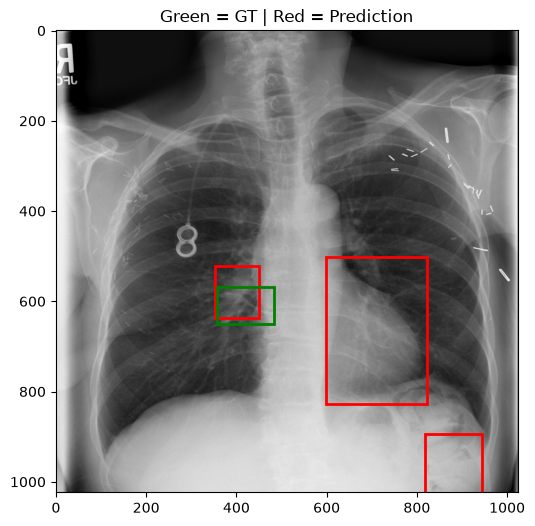

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# 选第一张
img_path = results[1].path
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, figsize=(6,6))
ax.imshow(img)

# 画预测框（红色）
for box in results[1].boxes.xyxy:
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

# 再画真实框（绿色）
for _, row in df_subset.iterrows():
    if row["Image Index"] in img_path:
        x = row["Bbox_x"]
        y = row["Bbox_y"]
        w = row["Bbox_w"]
        h = row["Bbox_h"]

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(rect)

plt.title("Green = GT | Red = Prediction")
plt.show()

classffication

In [26]:
import pandas as pd
import os

df_entry = pd.read_csv("F:/python/nih/Data_Entry_2017.csv")

print("总行数:", len(df_entry))
print("列名:", df_entry.columns.tolist())
print(df_entry.head())

img_dir = "F:/python/nih/images_001/images/"
files = os.listdir(img_dir)

print("images_001 图片数量:", len(files))

df_local = df_entry[df_entry['Image Index'].isin(files)]
print("匹配到的图片数量:", len(df_local))

总行数: 112120
列名: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA 

label
No Finding            2754
Infiltration           490
Atelectasis            460
Effusion               281
Cardiomegaly           173
Consolidation          160
Fibrosis               138
Nodule                 115
Emphysema               90
Pneumothorax            90
Mass                    81
Pleural_Thickening      66
Edema                   59
Hernia                  24
Pneumonia               18
Name: count, dtype: int64


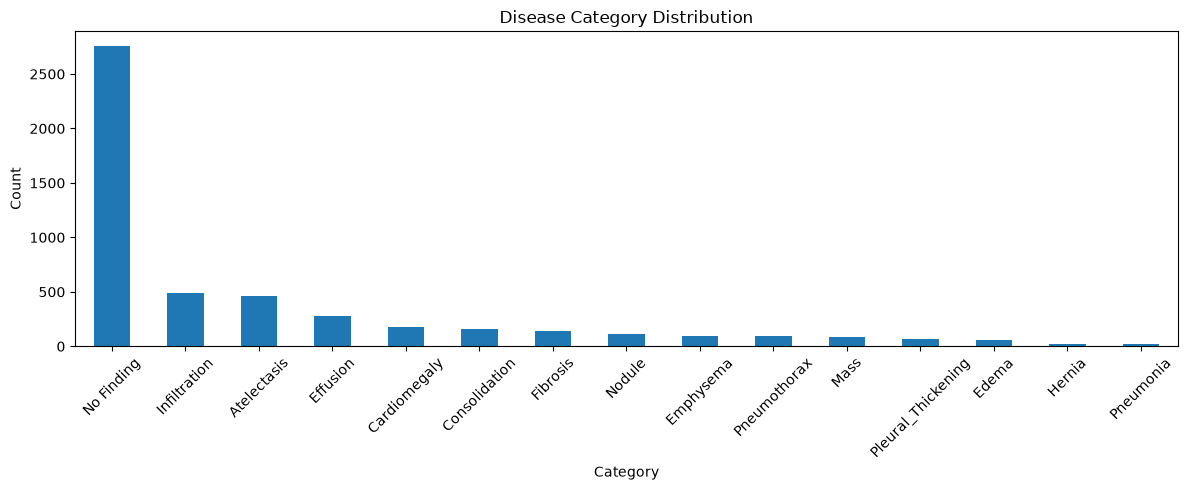

In [27]:
import matplotlib.pyplot as plt

df_local = df_local.copy()
df_local['label'] = df_local['Finding Labels'].apply(
    lambda x: x.split('|')[0]
)

label_counts = df_local['label'].value_counts()
print(label_counts)

label_counts.plot(kind='bar', figsize=(12,5))
plt.title('Disease Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
classes = df_local['label'].unique().tolist()
class_to_id = {c: i for i, c in enumerate(classes)}
df_local['label_id'] = df_local['label'].map(class_to_id)

print(f"类别数: {len(classes)}")
print(class_to_id)

类别数: 15
{'Cardiomegaly': 0, 'No Finding': 1, 'Hernia': 2, 'Mass': 3, 'Infiltration': 4, 'Effusion': 5, 'Nodule': 6, 'Emphysema': 7, 'Atelectasis': 8, 'Pleural_Thickening': 9, 'Pneumothorax': 10, 'Fibrosis': 11, 'Consolidation': 12, 'Edema': 13, 'Pneumonia': 14}


data set

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class NIHClassDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label_id'])
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = NIHClassDataset(df_local, img_dir, transform)
print("Dataset 大小:", len(dataset))

# 测试一个样本
image, label = dataset[0]
print("图片 shape:", image.shape)
print("标签:", label, "→", classes[label])

Dataset 大小: 4999
图片 shape: torch.Size([3, 224, 224])
标签: 0 → Cardiomegaly


划分 train/val

In [30]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=0
)

print("训练集:", len(train_dataset))
print("验证集:", len(val_dataset))

训练集: 3999
验证集: 1000


ResNet18

In [31]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from torchvision.models import ResNet18_Weights

# ROCm 下禁用 MIOpen（RDNA2 兼容性修复）
import torch
torch.backends.cudnn.enabled = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("模型加载完成")
print(f"输出类别数: {len(classes)}")

使用设备: cuda
模型加载完成
输出类别数: 15


loss_history = []
acc_history = []

num_epochs = 3

for epoch in range(num_epochs):
    # 训练
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    # 验证
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    acc_history.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Loss: {avg_loss:.4f} '
          f'Val Accuracy: {val_acc:.2f}%')

print("训练完成!")

In [32]:
loss_history = []
acc_history = []

num_epochs = 5

for epoch in range(num_epochs):
    # 训练
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Batch [{i}/{len(train_loader)}] '
                  f'Loss: {loss.item():.4f}')

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    # 验证
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    acc_history.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Loss: {avg_loss:.4f} '
          f'Val Accuracy: {val_acc:.2f}%')

print("训练完成!")

Epoch [1/5] Batch [0/250] Loss: 2.6312
Epoch [1/5] Batch [50/250] Loss: 1.4174
Epoch [1/5] Batch [100/250] Loss: 2.0902


KeyboardInterrupt: 

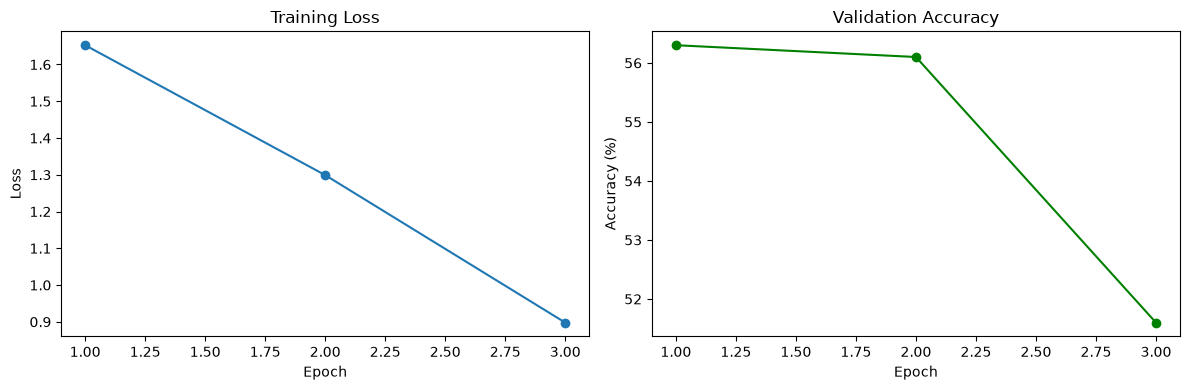

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), loss_history, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, num_epochs+1), acc_history, 
         marker='o', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

re trian

optimiaze

In [33]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [34]:
optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [35]:
# 重新标签编码
classes = df_disease['label'].unique().tolist()
class_to_id = {c: i for i, c in enumerate(classes)}
df_disease['label_id'] = df_disease['label'].map(class_to_id)

print(f"类别数: {len(classes)}")
print(f"总图片数: {len(df_disease)}")

# 重建 Dataset
train_dataset = NIHClassDataset(
    df_disease.iloc[:int(0.8*len(df_disease))],
    img_dir,
    transform_train
)

val_dataset = NIHClassDataset(
    df_disease.iloc[int(0.8*len(df_disease)):],
    img_dir,
    transform_val
)

# Windows Jupyter 下 num_workers 必须为 0（多进程会死锁）
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("训练集:", len(train_dataset))
print("验证集:", len(val_dataset))

# 重新加载模型
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# 训练
loss_history = []
acc_history = []
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    acc_history.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Loss: {avg_loss:.4f} '
          f'Val Accuracy: {val_acc:.2f}%')

print("训练完成!")

去掉 No Finding 后: 2245
label
Infiltration          490
Atelectasis           460
Effusion              281
Cardiomegaly          173
Consolidation         160
Fibrosis              138
Nodule                115
Emphysema              90
Pneumothorax           90
Mass                   81
Pleural_Thickening     66
Edema                  59
Hernia                 24
Pneumonia              18
Name: count, dtype: int64


In [ ]:
# 重新标签编码
classes = df_disease['label'].unique().tolist()
class_to_id = {c: i for i, c in enumerate(classes)}
df_disease['label_id'] = df_disease['label'].map(class_to_id)

print(f"类别数: {len(classes)}")
print(f"总图片数: {len(df_disease)}")

# 重建 Dataset
train_dataset = NIHClassDataset(
    df_disease.iloc[:int(0.8*len(df_disease))],
    img_dir,
    transform_train
)

val_dataset = NIHClassDataset(
    df_disease.iloc[int(0.8*len(df_disease)):],
    img_dir,
    transform_val
)

# RX 6600M 8GB：batch 调到 64
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("训练集:", len(train_dataset))
print("验证集:", len(val_dataset))

# 重新加载模型
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# 训练
loss_history = []
acc_history = []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Batch [{i}/{len(train_loader)}] '
                  f'Loss: {loss.item():.4f}')

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    acc_history.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Loss: {avg_loss:.4f} '
          f'Val Accuracy: {val_acc:.2f}%')

print("训练完成!")

类别数: 14
总图片数: 2245
训练集: 1796
验证集: 449


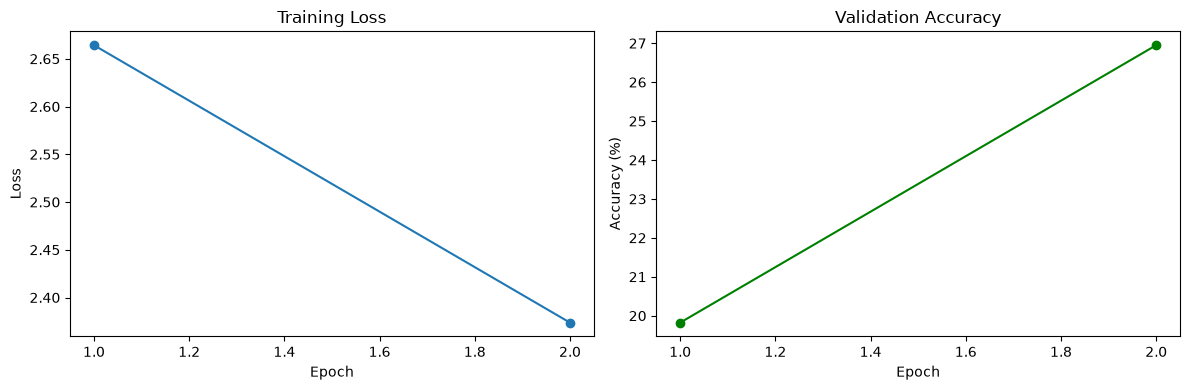

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), loss_history, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, num_epochs+1), acc_history, 
         marker='o', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()